In [2]:
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import numpy as np

$m \ddot{x} = - \rho \dot{x}$

$m \ddot{y} = - m g - \rho \dot{y} $

$\dot{x} = v_x$

$\therefore m \dot{v_x} = - \rho v_x$

$\dot{y} = v_y$

$\therefore m \dot{v_y} = -mg - \rho v_y $

In [31]:
# Newton-Raphson

def solveN(m, v0, theta, g, rho):
    vy0 = v0 * np.sin(theta)
    def f(t):
        return ( ( (vy0 * m / rho) + (g * m**2 / rho**2) ) * (1 - (np.exp(-rho * t / m))) ) - (g * m * t / rho)

    def diff(x):
        err = 1e-10
        return (f(x+err) - f(x))/(err)

    x0 = 5000
    xn = [x0]
    i = 0

    while i <= 10:
        xn.append(xn[i] - (f(xn[i]))/(diff(xn[i])))
        i+=1
    return xn[-1]

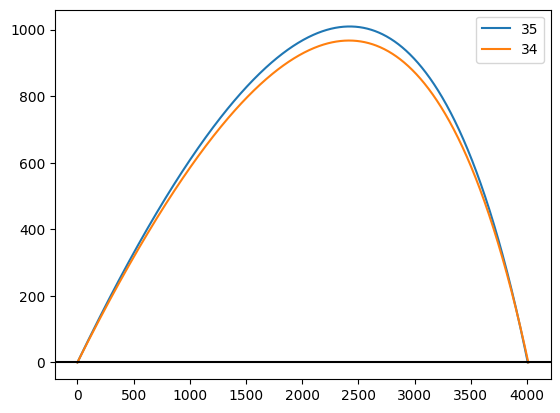

In [54]:
def diffeq(m, v0, theta, g, rho, lab=""):
    t = np.linspace(0, solveN(m, v0, theta, g, rho), 1000)
    vx0 = v0 * np.cos(theta)
    vy0 = v0 * np.sin(theta)
    x0 = 0
    y0 = 0
    S0 = [vx0, x0, vy0, y0]

    def dSdt(t, S):
        vx, x, vy, y = S
        return[- rho * vx / m,
            vx,
            - g - rho * vy / m,
            vy
            ]

    sol = odeint(dSdt, y0=S0, t=t, tfirst=True).T
    plt.plot(sol[1], sol[3], label=lab)

def param(m, v0, theta, g, rho, lab=""):
    t = np.linspace(0, solveN(m, v0, theta, g, rho), 1000)
    vx0 = v0 * np.cos(theta)
    vy0 = v0 * np.sin(theta)

    xvals = vx0 * m * (1 - (np.exp(-rho * t / m))) / rho
    yvals = ( ( (vy0 * m / rho) + (g * m**2 / rho**2) ) * (1 - (np.exp(-rho * t / m))) ) - (g * m * t / rho)

    plt.plot(xvals, yvals, label=lab)

# m, v0, theta, g, rho, t
# diffeq(9, 300, np.pi/6, 9.81, 0.4, "30")
diffeq(9, 300, np.deg2rad(35), 9.81, 0.4, "35")
diffeq(9, 300, np.deg2rad(34), 9.81, 0.4, "34")
# param(9, 300, np.pi/4, 9.81, 0.4, "45")
# param(9, 300, np.pi/3, 9.81, 0.4, "60")
plt.legend()

plt.axhline(0, color="black")

jupyter-kernelspec uninstall venv to delete